In [1]:
"""
ECGR 4106 - Homework 5
Samantha Gonzalez
801353957
"""

# ============================================================
# 0. Install and import libraries
# ============================================================

import time
import math
import os
import random
import sys
import subprocess
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def install_if_missing(package_name, import_name=None):
    # This helps in Colab because sometimes a package is not installed yet.
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])


# In Google Colab these are usually already installed or install quickly.
install_if_missing("transformers")
install_if_missing("torchinfo")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100
from torchvision import models

from torchinfo import summary
from transformers import SwinForImageClassification

In [2]:
# ============================================================
# 1. Basic setup
# ============================================================

def set_seed(seed=42):
    # I used a seed so that the results are easier to repeat.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# These are the homework hyperparameters.
VIT_BATCH_SIZE = 64
VIT_EPOCHS = 10
VIT_LR = 0.001

SWIN_BATCH_SIZE = 32
SWIN_EPOCHS = 5
SWIN_PRETRAINED_LR = 2e-5
SWIN_SCRATCH_LR = 0.001

NUM_CLASSES = 100
DATA_DIR = "./data"

# Set this to True if you just want to test that the code runs quickly.
# For final homework results, keep it False.
USE_SMALL_DEBUG_SET = False

Using device: cuda


In [3]:
# ============================================================
# 2. Data loading
# ============================================================

# For the scratch ViT and ResNet, I use CIFAR-100 at its normal 32x32 size.
transform_32_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])

transform_32_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])

# For pretrained Swin models, the images need to be resized to 224x224.
# This is because the pretrained models were trained on ImageNet-style images.
transform_224_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transform_224_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


def make_loaders(transform_train, transform_test, batch_size):
    train_dataset = CIFAR100(
        root=DATA_DIR,
        train=True,
        download=True,
        transform=transform_train
    )
    test_dataset = CIFAR100(
        root=DATA_DIR,
        train=False,
        download=True,
        transform=transform_test
    )

    # This is only for debugging the notebook quickly.
    if USE_SMALL_DEBUG_SET:
        train_dataset = Subset(train_dataset, list(range(2000)))
        test_dataset = Subset(test_dataset, list(range(500)))

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    return train_loader, test_loader


vit_train_loader, vit_test_loader = make_loaders(
    transform_32_train,
    transform_32_test,
    VIT_BATCH_SIZE
)

swin_train_loader, swin_test_loader = make_loaders(
    transform_224_train,
    transform_224_test,
    SWIN_BATCH_SIZE
)

100%|██████████| 169M/169M [31:42<00:00, 88.8kB/s]


In [4]:
# ============================================================
# 3. Helper functions for training and evaluation
# ============================================================

def count_parameters(model):
    # This counts only the trainable parameters.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_all_parameters(model):
    # This counts every parameter, including frozen ones.
    return sum(p.numel() for p in model.parameters())


def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Hugging Face models return an object with logits.
        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_time = time.time() - start_time
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, epoch_time


def evaluate(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def train_model(model, train_loader, test_loader, epochs, lr, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    history = []
    total_start = time.time()

    print("\n=================================================")
    print("Training:", model_name)
    print("=================================================")

    for epoch in range(epochs):
        train_loss, train_acc, epoch_time = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
            "epoch_time_sec": epoch_time
        })

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}% | "
            f"Time: {epoch_time:.2f} sec"
        )

    total_time = time.time() - total_start
    return history, total_time


def estimate_flops_with_torchinfo(model, input_size):
    # torchinfo gives multiply-adds. I am using it as a FLOPs estimate.
    try:
        model_cpu = model.to("cpu")
        info = summary(
            model_cpu,
            input_size=input_size,
            verbose=0,
            col_names=["num_params", "mult_adds"]
        )
        model.to(device)
        return int(info.total_mult_adds)
    except Exception as e:
        print("torchinfo FLOP estimate failed:", e)
        model.to(device)
        return None

In [5]:
# ============================================================
# 4. Problem 1 - Vision Transformer from scratch
# ============================================================

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Conv2d is an easy way to split the image into patches and project them.
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)              # shape: batch, embed_dim, grid, grid
        x = x.flatten(2)              # shape: batch, embed_dim, num_patches
        x = x.transpose(1, 2)         # shape: batch, num_patches, embed_dim
        return x


class ViTFromScratch(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=100,
        embed_dim=256,
        num_blocks=4,
        num_heads=4,
        mlp_dim=1024,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        # The class token is the token used for the final classification.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_blocks
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        # These are simple initializations commonly used for Transformer models.
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.encoder(x)
        x = self.norm(x)

        cls_output = x[:, 0]
        logits = self.head(cls_output)
        return logits


def manual_vit_flops(image_size, patch_size, embed_dim, num_blocks, num_heads, mlp_dim, num_classes=100):
    """
    This is a simple FLOPs estimate for one forward pass.
    It is not perfect, but it is useful for comparing configurations.
    """
    num_patches = (image_size // patch_size) ** 2
    tokens = num_patches + 1

    # Patch projection cost.
    patch_flops = num_patches * (patch_size * patch_size * 3) * embed_dim

    # Attention block estimate:
    # qkv projections + attention matrix + attention/value multiply + output projection
    attention_flops = (
        3 * tokens * embed_dim * embed_dim
        + 2 * num_heads * tokens * tokens * (embed_dim // num_heads)
        + tokens * embed_dim * embed_dim
    )

    # MLP cost: embed -> mlp -> embed
    mlp_flops = 2 * tokens * embed_dim * mlp_dim

    block_flops = attention_flops + mlp_flops
    classifier_flops = embed_dim * num_classes

    return int(patch_flops + num_blocks * block_flops + classifier_flops)


# At least four ViT configurations are required. I chose these to show
# smaller and larger patch sizes and model sizes.
vit_configs = [
    {"patch_size": 4, "embed_dim": 256, "num_blocks": 4, "num_heads": 4},
    {"patch_size": 4, "embed_dim": 256, "num_blocks": 8, "num_heads": 8},
    {"patch_size": 8, "embed_dim": 256, "num_blocks": 4, "num_heads": 4},
    {"patch_size": 8, "embed_dim": 512, "num_blocks": 8, "num_heads": 8},
]

problem1_results = []

for config in vit_configs:
    mlp_dim = 4 * config["embed_dim"]

    model_name = (
        f"ViT_P{config['patch_size']}_D{config['embed_dim']}"
        f"_B{config['num_blocks']}_H{config['num_heads']}"
    )

    vit_model = ViTFromScratch(
        image_size=32,
        patch_size=config["patch_size"],
        embed_dim=config["embed_dim"],
        num_blocks=config["num_blocks"],
        num_heads=config["num_heads"],
        mlp_dim=mlp_dim,
        num_classes=NUM_CLASSES
    )

    params = count_parameters(vit_model)
    flops = manual_vit_flops(
        image_size=32,
        patch_size=config["patch_size"],
        embed_dim=config["embed_dim"],
        num_blocks=config["num_blocks"],
        num_heads=config["num_heads"],
        mlp_dim=mlp_dim,
        num_classes=NUM_CLASSES
    )

    history, total_time = train_model(
        vit_model,
        vit_train_loader,
        vit_test_loader,
        VIT_EPOCHS,
        VIT_LR,
        model_name
    )

    final_test_acc = history[-1]["test_accuracy"]
    avg_epoch_time = np.mean([h["epoch_time_sec"] for h in history])

    problem1_results.append({
        "model": model_name,
        "patch_size": config["patch_size"],
        "embed_dim": config["embed_dim"],
        "blocks": config["num_blocks"],
        "heads": config["num_heads"],
        "mlp_dim": mlp_dim,
        "test_accuracy": final_test_acc,
        "parameters": params,
        "estimated_flops": flops,
        "avg_epoch_time_sec": avg_epoch_time,
        "total_training_time_sec": total_time
    })


Training: ViT_P4_D256_B4_H4
Epoch 1/10 | Train Loss: 4.3719 | Train Acc: 3.39% | Test Acc: 2.58% | Time: 16.16 sec
Epoch 2/10 | Train Loss: 4.5118 | Train Acc: 2.10% | Test Acc: 2.03% | Time: 14.35 sec
Epoch 3/10 | Train Loss: 4.4732 | Train Acc: 2.29% | Test Acc: 2.19% | Time: 14.64 sec
Epoch 4/10 | Train Loss: 4.5134 | Train Acc: 2.01% | Test Acc: 1.86% | Time: 14.53 sec
Epoch 5/10 | Train Loss: 4.5997 | Train Acc: 1.18% | Test Acc: 1.22% | Time: 14.76 sec
Epoch 6/10 | Train Loss: 4.5902 | Train Acc: 1.27% | Test Acc: 1.46% | Time: 14.73 sec
Epoch 7/10 | Train Loss: 4.5932 | Train Acc: 1.30% | Test Acc: 1.01% | Time: 14.63 sec
Epoch 8/10 | Train Loss: 4.5926 | Train Acc: 1.34% | Test Acc: 1.00% | Time: 14.57 sec
Epoch 9/10 | Train Loss: 4.5887 | Train Acc: 1.45% | Test Acc: 1.00% | Time: 14.54 sec
Epoch 10/10 | Train Loss: 4.5642 | Train Acc: 1.62% | Test Acc: 1.00% | Time: 14.62 sec

Training: ViT_P4_D256_B8_H8
Epoch 1/10 | Train Loss: 4.6308 | Train Acc: 1.06% | Test Acc: 1.00% | 


Training: ResNet18_Scratch
Epoch 1/10 | Train Loss: 3.5612 | Train Acc: 15.68% | Test Acc: 23.07% | Time: 14.24 sec
Epoch 2/10 | Train Loss: 2.8339 | Train Acc: 28.30% | Test Acc: 32.57% | Time: 13.96 sec
Epoch 3/10 | Train Loss: 2.4447 | Train Acc: 36.08% | Test Acc: 37.85% | Time: 13.63 sec
Epoch 4/10 | Train Loss: 2.1915 | Train Acc: 41.56% | Test Acc: 41.11% | Time: 13.74 sec
Epoch 5/10 | Train Loss: 1.9847 | Train Acc: 46.04% | Test Acc: 43.06% | Time: 13.80 sec
Epoch 6/10 | Train Loss: 1.8011 | Train Acc: 50.42% | Test Acc: 44.80% | Time: 13.83 sec
Epoch 7/10 | Train Loss: 1.6429 | Train Acc: 54.08% | Test Acc: 46.55% | Time: 13.91 sec
Epoch 8/10 | Train Loss: 1.4830 | Train Acc: 57.76% | Test Acc: 46.28% | Time: 13.83 sec
Epoch 9/10 | Train Loss: 1.3431 | Train Acc: 61.18% | Test Acc: 48.34% | Time: 13.77 sec
Epoch 10/10 | Train Loss: 1.1956 | Train Acc: 65.15% | Test Acc: 48.93% | Time: 14.03 sec

Problem 1 Results:
               model patch_size embed_dim blocks heads mlp_di

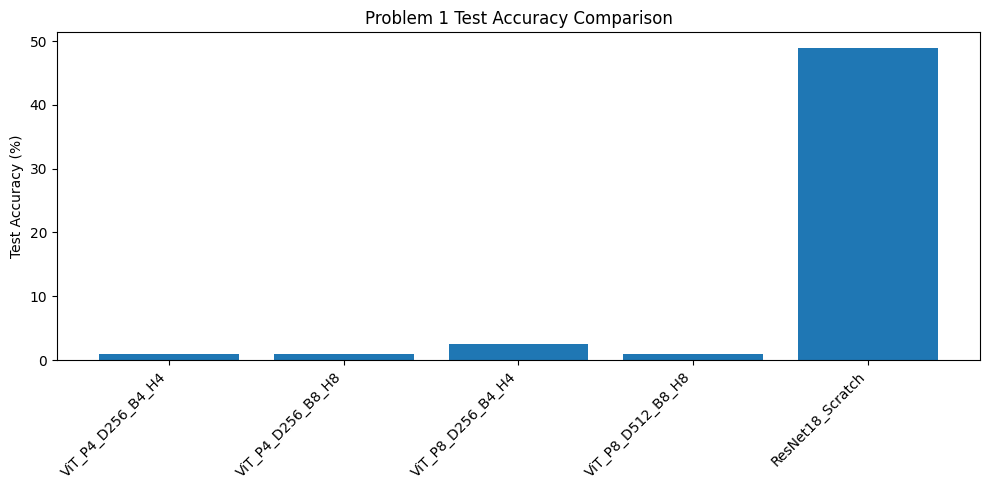

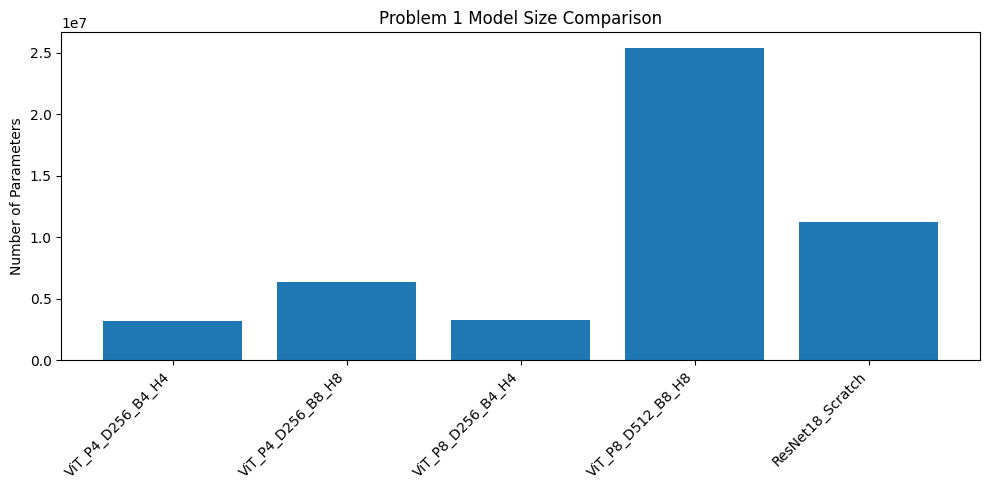

In [6]:
# ============================================================
# 5. Problem 1 - ResNet-18 baseline
# ============================================================

# I am using a standard torchvision ResNet-18 and changing the last layer
# so it predicts 100 CIFAR-100 classes.
resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(resnet18.fc.in_features, NUM_CLASSES)

resnet_params = count_parameters(resnet18)
resnet_flops = estimate_flops_with_torchinfo(
    resnet18,
    input_size=(1, 3, 32, 32)
)

resnet_history, resnet_total_time = train_model(
    resnet18,
    vit_train_loader,
    vit_test_loader,
    VIT_EPOCHS,
    VIT_LR,
    "ResNet18_Scratch"
)

problem1_results.append({
    "model": "ResNet18_Scratch",
    "patch_size": "N/A",
    "embed_dim": "N/A",
    "blocks": "N/A",
    "heads": "N/A",
    "mlp_dim": "N/A",
    "test_accuracy": resnet_history[-1]["test_accuracy"],
    "parameters": resnet_params,
    "estimated_flops": resnet_flops,
    "avg_epoch_time_sec": np.mean([h["epoch_time_sec"] for h in resnet_history]),
    "total_training_time_sec": resnet_total_time
})

problem1_df = pd.DataFrame(problem1_results)
print("\nProblem 1 Results:")
print(problem1_df)
problem1_df.to_csv("problem1_vit_resnet_results.csv", index=False)


# Plot Problem 1 accuracy.
plt.figure(figsize=(10, 5))
plt.bar(problem1_df["model"], problem1_df["test_accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy (%)")
plt.title("Problem 1 Test Accuracy Comparison")
plt.tight_layout()
plt.savefig("problem1_accuracy_comparison.png", dpi=200)
plt.show()


# Plot Problem 1 parameter count.
plt.figure(figsize=(10, 5))
plt.bar(problem1_df["model"], problem1_df["parameters"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Parameters")
plt.title("Problem 1 Model Size Comparison")
plt.tight_layout()
plt.savefig("problem1_parameter_comparison.png", dpi=200)
plt.show()

In [7]:
# ============================================================
# 6. Problem 2 - Pretrained Swin Transformer fine-tuning
# ============================================================

def load_pretrained_swin(model_name):
    """
    This loads a pretrained Swin model from Hugging Face.
    I use ignore_mismatched_sizes=True because CIFAR-100 has 100 classes,
    while the original ImageNet model has 1000 classes.
    """
    model = SwinForImageClassification.from_pretrained(
        model_name,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )

    # Freeze the backbone so only the classification head is trained.
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

    return model


problem2_results = []

pretrained_swin_models = [
    ("Swin-Tiny-Pretrained", "microsoft/swin-tiny-patch4-window7-224"),
    ("Swin-Small-Pretrained", "microsoft/swin-small-patch4-window7-224"),
]

for display_name, hf_name in pretrained_swin_models:
    swin_model = load_pretrained_swin(hf_name)

    total_params = count_all_parameters(swin_model)
    trainable_params = count_parameters(swin_model)

    history, total_time = train_model(
        swin_model,
        swin_train_loader,
        swin_test_loader,
        SWIN_EPOCHS,
        SWIN_PRETRAINED_LR,
        display_name
    )

    problem2_results.append({
        "model": display_name,
        "pretrained": "Yes",
        "frozen_backbone": "Yes",
        "test_accuracy": history[-1]["test_accuracy"],
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "avg_epoch_time_sec": np.mean([h["epoch_time_sec"] for h in history]),
        "total_training_time_sec": total_time
    })


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

...

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Training: Swin-Small-Pretrained


model.safetensors: reconstructing file:   0%|          |  0.00B /  199MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/5 | Train Loss: 3.9791 | Train Acc: 29.97% | Test Acc: 52.44% | Time: 188.56 sec
Epoch 2/5 | Train Loss: 2.8844 | Train Acc: 59.12% | Test Acc: 63.29% | Time: 188.35 sec
Epoch 3/5 | Train Loss: 2.1635 | Train Acc: 65.14% | Test Acc: 66.89% | Time: 188.22 sec
Epoch 4/5 | Train Loss: 1.7318 | Train Acc: 67.63% | Test Acc: 68.81% | Time: 187.98 sec
Epoch 5/5 | Train Loss: 1.4740 | Train Acc: 69.33% | Test Acc: 70.42% | Time: 188.29 sec



Training: Swin-Tiny-Scratch
Epoch 1/5 | Train Loss: 4.6626 | Train Acc: 1.18% | Test Acc: 1.00% | Time: 383.86 sec
Epoch 2/5 | Train Loss: 4.6252 | Train Acc: 0.94% | Test Acc: 1.00% | Time: 383.89 sec
Epoch 3/5 | Train Loss: 4.6138 | Train Acc: 0.97% | Test Acc: 1.00% | Time: 383.73 sec
Epoch 4/5 | Train Loss: 4.6135 | Train Acc: 1.05% | Test Acc: 1.00% | Time: 384.57 sec
Epoch 5/5 | Train Loss: 4.6096 | Train Acc: 1.06% | Test Acc: 1.00% | Time: 382.38 sec

Problem 2 Results:
                   model pretrained frozen_backbone  test_accuracy  \
0   Swin-Tiny-Pretrained        Yes             Yes          66.61   
1  Swin-Small-Pretrained        Yes             Yes          70.42   
2      Swin-Tiny-Scratch         No              No           1.00   

   total_parameters  trainable_parameters  avg_epoch_time_sec  \
0          27596254                 76900          110.907496   
1          48914158                 76900          188.278263   
2          27596254              2759625

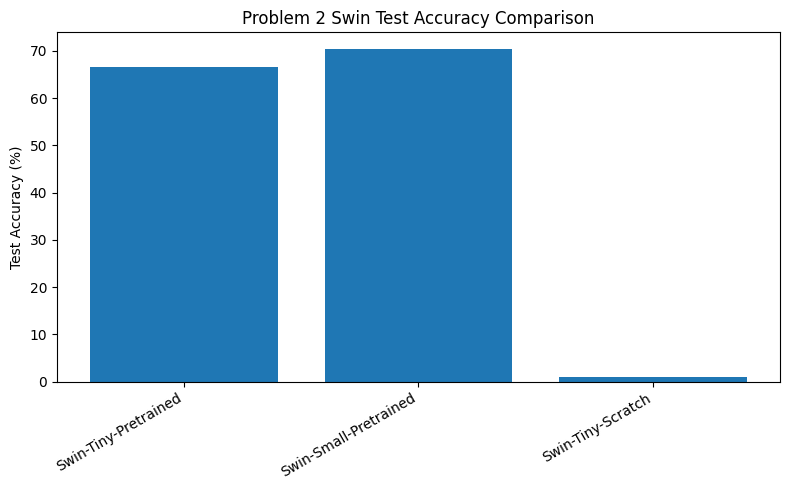

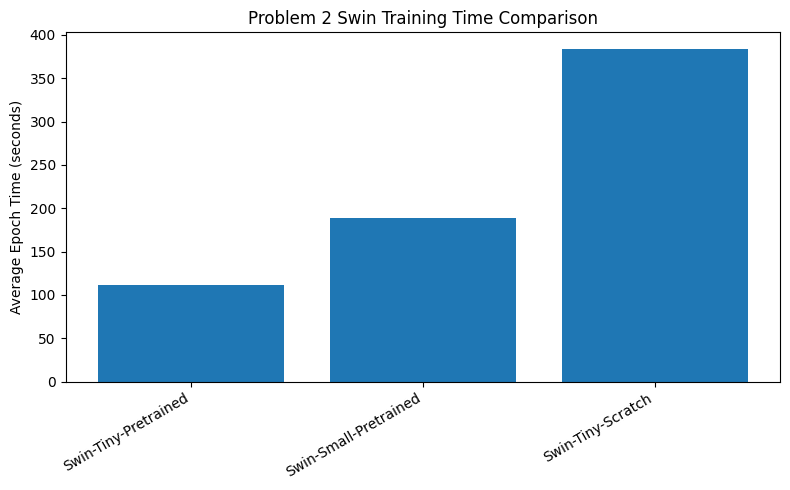

In [8]:
# ============================================================
# 7. Problem 2 - Swin Transformer trained from scratch
# ============================================================

# For the scratch Swin baseline, I use torchvision's Swin-T architecture with
# no pretrained weights. This is still trained from random initialization.
# Writing the whole Swin model by hand would be much longer and easier to mess up.
swin_scratch = models.swin_t(weights=None)
swin_scratch.head = nn.Linear(swin_scratch.head.in_features, NUM_CLASSES)

swin_scratch_params = count_all_parameters(swin_scratch)

swin_scratch_history, swin_scratch_total_time = train_model(
    swin_scratch,
    swin_train_loader,
    swin_test_loader,
    SWIN_EPOCHS,
    SWIN_SCRATCH_LR,
    "Swin-Tiny-Scratch"
)

problem2_results.append({
    "model": "Swin-Tiny-Scratch",
    "pretrained": "No",
    "frozen_backbone": "No",
    "test_accuracy": swin_scratch_history[-1]["test_accuracy"],
    "total_parameters": swin_scratch_params,
    "trainable_parameters": swin_scratch_params,
    "avg_epoch_time_sec": np.mean([h["epoch_time_sec"] for h in swin_scratch_history]),
    "total_training_time_sec": swin_scratch_total_time
})

problem2_df = pd.DataFrame(problem2_results)
print("\nProblem 2 Results:")
print(problem2_df)
problem2_df.to_csv("problem2_swin_results.csv", index=False)


# Plot Problem 2 accuracy.
plt.figure(figsize=(8, 5))
plt.bar(problem2_df["model"], problem2_df["test_accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test Accuracy (%)")
plt.title("Problem 2 Swin Test Accuracy Comparison")
plt.tight_layout()
plt.savefig("problem2_swin_accuracy.png", dpi=200)
plt.show()


# Plot Problem 2 training time.
plt.figure(figsize=(8, 5))
plt.bar(problem2_df["model"], problem2_df["avg_epoch_time_sec"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average Epoch Time (seconds)")
plt.title("Problem 2 Swin Training Time Comparison")
plt.tight_layout()
plt.savefig("problem2_swin_training_time.png", dpi=200)
plt.show()

In [9]:
# ============================================================
# 8. Final combined summary
# ============================================================

print("\n=================================================")
print("Final Homework 5 Summary")
print("=================================================")

print("\nProblem 1: ViT from scratch vs ResNet-18")
print(problem1_df)

print("\nProblem 2: pretrained Swin vs scratch Swin")
print(problem2_df)

print("\nSaved files:")
print("- problem1_vit_resnet_results.csv")
print("- problem2_swin_results.csv")
print("- problem1_accuracy_comparison.png")
print("- problem1_parameter_comparison.png")
print("- problem2_swin_accuracy.png")
print("- problem2_swin_training_time.png")


Final Homework 5 Summary

Problem 1: ViT from scratch vs ResNet-18
               model patch_size embed_dim blocks heads mlp_dim  test_accuracy  \
0  ViT_P4_D256_B4_H4          4       256      4     4    1024           1.00   
1  ViT_P4_D256_B8_H8          4       256      8     8    1024           1.00   
2  ViT_P8_D256_B4_H4          8       256      4     4    1024           2.48   
3  ViT_P8_D512_B8_H8          8       512      8     8    2048           1.00   
4   ResNet18_Scratch        N/A       N/A    N/A   N/A     N/A          48.93   

   parameters  estimated_flops  avg_epoch_time_sec  total_training_time_sec  
0     3214692        213937152           14.753147               161.979023  
1     6373732        427062272           31.102826               327.626302  
2     3239268         54881280            9.975596               114.638917  
3    25379428        431810560           27.450561               288.929831  
4    11227812         37072356           13.875563     